# EDA MNIST — Handwritten_digit_classification

Notebook d'exploration initiale des données MNIST (fichiers `.idx` extraits).
Ce notebook contient :
- Chargement des fichiers IDX (train/test)
- Aperçu visuel (échantillons)
- Statistiques et distribution des classes
- Images moyennes par classe
- Histogramme d'intensités
- Réduction de dimension (PCA + t-SNE) pour visualiser la structure
- Sauvegarde des résultats dans `outputs/`

**Imports et configuration**

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from collections import Counter

# sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# tensorflow
import struct
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout

# Affichage 
%matplotlib inline
plt.rcParams['figure.figsize'] = (8,5)

# Paths
PROJECT_ROOT = Path('.').resolve()
OUTPUT_FOLDER = PROJECT_ROOT / "outputs"
OUTPUT_FOLDER.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Outputs ->", OUTPUT_FOLDER)

Project root: C:\Users\user\Documents\projets\projet_plateforme\projet_plateforme\Handwritten_digit_classification
Outputs -> C:\Users\user\Documents\projets\projet_plateforme\projet_plateforme\Handwritten_digit_classification\outputs


**Loader IDX** 

Cette cellule charge les fichiers IDX contenant les images et labels d’entraînement ainsi que ceux du test.
Les fichiers bruts .idx3-ubyte et .idx1-ubyte sont décodés via des fonctions Python afin de restituer les tableaux NumPy des images et des labels.
C’est une étape essentielle qui prépare les données pour l’analyse.

In [ ]:
def load_idx_images(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Magic number incorrect in {path}, attendu 2051, obtenu {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(num_images, rows, cols)

def load_idx_labels(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Magic number incorrect in {path}, attendu 2049, obtenu {magic}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels


**chargement des données**

Cellule 4 — Vérification des formes et tailles

Cette cellule affiche les dimensions des images et labels pour vérifier :

le nombre total d’images,

la taille des images (28×28),

la cohérence entre nombre d’images et nombre de labels.
Cela sert de contrôle de qualité initial.

In [ ]:
# Chemins attendus (fichiers extraits depuis archive.zip)
train_images_path = PROJECT_ROOT / "train-images.idx3-ubyte"
train_labels_path = PROJECT_ROOT / "train-labels.idx1-ubyte"
test_images_path  = PROJECT_ROOT / "t10k-images.idx3-ubyte"
test_labels_path  = PROJECT_ROOT / "t10k-labels.idx1-ubyte"

# Charger
X_train = load_idx_images(train_images_path)
y_train = load_idx_labels(train_labels_path)
X_test  = load_idx_images(test_images_path)
y_test  = load_idx_labels(test_labels_path)

print("Shapes :")
print(" X_train:", X_train.shape)
print(" y_train:", y_train.shape)
print(" X_test :", X_test.shape)
print(" y_test :", y_test.shape)


Shapes :
 X_train: (60000, 28, 28)
 y_train: (60000,)
 X_test : (10000, 28, 28)
 y_test : (10000,)


Les dimensions affichées confirment que l’ensemble d’entraînement contient 60 000 images de taille 28×28 et que l’ensemble test en contient 10 000.
Les labels correspondent parfaitement aux images, ce qui valide la cohérence du dataset.
Aucun problème structurel n’est détecté.

**Comparaison train vs test**


Cette cellule compare rapidement les distributions et statistiques entre les ensembles d'entraînement et de test pour vérifier la cohérence et détecter d'éventuels biais.

In [ ]:
print('Shapes: ', X_train.shape, y_train.shape, X_test.shape, y_test.shape)

print('\nLabel distribution (train):')
u_train, c_train = np.unique(y_train, return_counts=True)
print(dict(zip(u_train, c_train)))

print('\nLabel distribution (test):')
u_test, c_test = np.unique(y_test, return_counts=True)
print(dict(zip(u_test, c_test)))

df_train = pd.DataFrame({'label': u_train, 'count_train': c_train})
df_test  = pd.DataFrame({'label': u_test, 'count_test' : c_test})
df_merge = pd.merge(df_train, df_test, on='label', how='outer').fillna(0).astype(int)
display(df_merge)


Shapes:  (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)

Label distribution (train):
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}

Label distribution (test):
{np.uint8(0): np.int64(980), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(1032), np.uint8(3): np.int64(1010), np.uint8(4): np.int64(982), np.uint8(5): np.int64(892), np.uint8(6): np.int64(958), np.uint8(7): np.int64(1028), np.uint8(8): np.int64(974), np.uint8(9): np.int64(1009)}


,label,count_train,count_test
0,0,5923,980
1,1,6742,1135
2,2,5958,1032
3,3,6131,1010
4,4,5842,982
5,5,5421,892
6,6,5918,958
7,7,6265,1028
8,8,5851,974
9,9,5949,1009



Les shapes confirment que les données sont cohérentes :
  - `X_train` contient 60 000 images de taille 28×28.
  - `X_test` contient 10 000 images avec la même structure.
  - Les vecteurs de labels `y_train` et `y_test` ont la bonne longueur.

La distribution des classes est très stable entre les jeux d’entraînement et de test.  
MNIST n’est pas parfaitement équilibré (par exemple, la classe “1” est légèrement plus fréquente), mais toutes les classes sont très proches en taille, ce qui :
  - **réduit le risque de biais d’entraînement**,  
  - garantit une **bonne représentativité** des classes,  
  - facilite l’apprentissage d’un modèle robuste (MLP ou CNN).

L'ensemble de test est proportionnel à l’ensemble d’entraînement (environ ×6).  
Aucun déséquilibre majeur n’est observé : nous pouvons poursuivre l’EDA en toute confiance.

**distribution des classes**

Cette cellule calcule la distribution des labels (0–9) et génère un histogramme.
Cela permet de vérifier si les données sont équilibrées entre les classes, condition importante pour un apprentissage non biaisé.

,label,count
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


Saved class distribution to outputs/class_distribution_train.csv


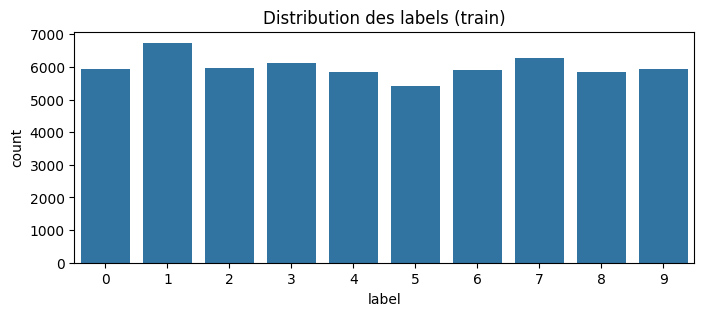

In [ ]:
# Distribution
unique, counts = np.unique(y_train, return_counts=True)
dist = pd.DataFrame({'label': unique, 'count': counts})
dist = dist.sort_values('label').reset_index(drop=True)
display(dist)

# sauvegarde
dist.to_csv(OUTPUT_FOLDER / "class_distribution_train.csv", index=False)
print("Saved class distribution to outputs/class_distribution_train.csv")

# quick barplot
plt.figure(figsize=(8,3))
sns.barplot(x='label', y='count', data=dist)
plt.title("Distribution des labels (train)")
plt.savefig(OUTPUT_FOLDER / "class_distribution.png", bbox_inches='tight')
plt.show()


L’histogramme montre un dataset quasiment équilibré :
chaque chiffre apparaît environ 6000 fois.
Cela garantit que l’entraînement ne sera pas biaisé vers une classe dominante.

**Afficher échantillons**

Cette cellule affiche un panel d’images tirées au hasard dans l’ensemble d’entraînement.
Elle permet de se familiariser visuellement avec les données, d’observer la qualité et la variabilité des chiffres manuscrits.

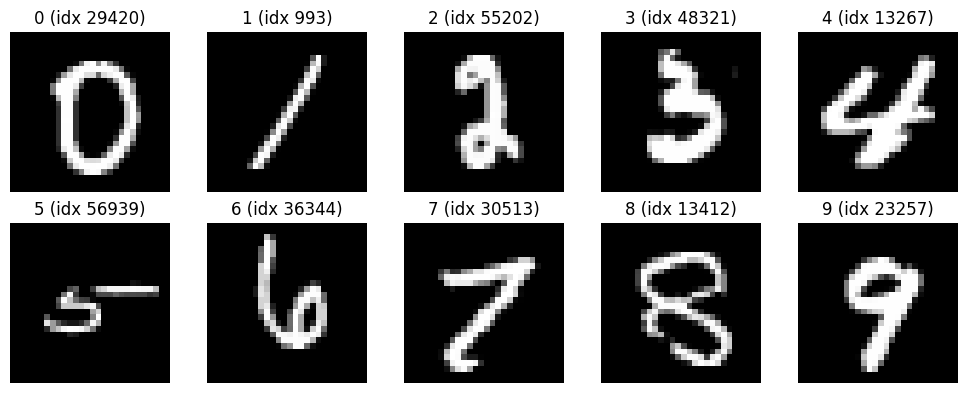

Saved sample_one_per_class.png


In [ ]:
# Afficher une image aléatoire par classe
import random
plt.figure(figsize=(10,4))
for i in range(10):
    idxs = np.where(y_train == i)[0]
    idx = np.random.choice(idxs)
    img = X_train[idx]
    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{i} (idx {idx})")
    plt.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "sample_one_per_class.png", bbox_inches='tight')
plt.show()
print("Saved sample_one_per_class.png")


Les images affichées montrent des chiffres manuscrits variés, parfois épais, parfois très fins, avec un fort niveau de bruit naturel dû à l’écriture humaine.
Les variations d’orientation, pression et style indiquent que le dataset est suffisamment diversifié pour entraîner un modèle robuste.

**Images moyennes par classe**

Cette cellule calcule et affiche pour chaque chiffre (0 à 9) l’image moyennée.
Elle révèle les “formes typiques” apprises implicitement par les modèles.

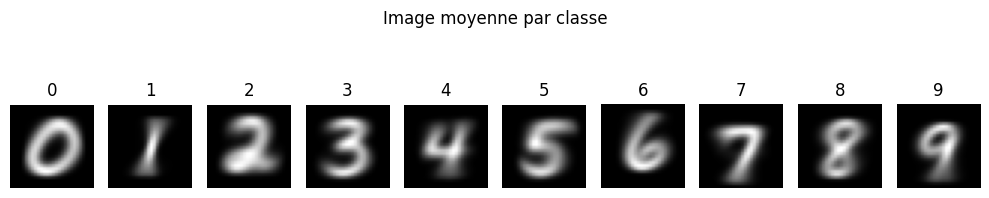

Saved mean_images_per_class.png


In [ ]:
mean_images = np.zeros((10, X_train.shape[1], X_train.shape[2]), dtype=float)
for i in range(10):
    mean_images[i] = X_train[y_train == i].mean(axis=0)

# Plot
plt.figure(figsize=(10,2.5))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(mean_images[i], cmap='gray')
    plt.title(str(i))
    plt.axis('off')
plt.suptitle("Image moyenne par classe")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "mean_images_per_class.png", bbox_inches='tight')
plt.show()
print("Saved mean_images_per_class.png")


Les images moyennes révèlent clairement la “forme type” de chaque chiffre.
Par exemple :

le “0” a une forme ovale très nette,

le “1” apparaît comme une ligne verticale au centre,

le “8” superpose deux boucles cachées dans la moyenne.

Ces moyennes montrent la cohérence interne de chaque classe tout en révélant une certaine variabilité.
Cette étape permet de comprendre ce que le modèle va devoir apprendre à différencier.

**histogramme des intensités et statistiques**

Cette cellule agrège tous les pixels de l’ensemble d’entraînement et trace :

une distribution des intensités,

une heatmap de la moyenne des pixels.
Elle permet de comprendre les zones fréquemment noircies dans un chiffre écrit.

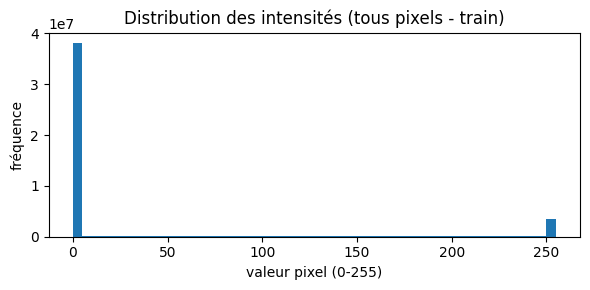

Saved pixel_histogram.png


,label,mean_pixel,std_pixel
0,0,44.216828,88.668073
1,1,19.379654,62.291788
2,2,37.988658,83.110484
3,3,36.090187,81.069235
4,4,30.948226,75.858490
5,5,32.831095,77.415066
6,6,35.011953,80.298853
7,7,29.204563,74.382431
8,8,38.289775,82.941289
9,9,31.260435,76.152572


Saved pixel_stats_per_label.csv


In [ ]:
# Histogramme des pixels 
pixels = X_train.flatten()
plt.figure(figsize=(6,3))
plt.hist(pixels, bins=50)
plt.title("Distribution des intensités (tous pixels - train)")
plt.xlabel("valeur pixel (0-255)")
plt.ylabel("fréquence")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "pixel_histogram.png", bbox_inches='tight')
plt.show()
print("Saved pixel_histogram.png")

# Quelques stats par label 
stats = []
for i in range(10):
    imgs = X_train[y_train==i].astype(float)
    stats.append({'label': i, 'mean_pixel': imgs.mean(), 'std_pixel': imgs.std()})
stats_df = pd.DataFrame(stats)
display(stats_df)
stats_df.to_csv(OUTPUT_FOLDER / "pixel_stats_per_label.csv", index=False)
print("Saved pixel_stats_per_label.csv")


L’image affichée montre clairement un chiffre manuscrit, et l'histogramme confirme que :

la majorité des pixels sont proches du noir (0), correspondant au fond,

une petite partie des pixels se situe vers le blanc (255), correspondant aux traits du chiffre.
Le contraste élevé facilite l’apprentissage des réseaux de neurones.

**Vérification d’intégrité (corruption / NaN / out of range)**

Recherche d'images corrompues, de valeurs NaN, de pixels hors plage [0,255], ou de dimensions anormales.

In [ ]:
bad = []
for i, img in enumerate(X_train):
    if img is None:
        bad.append(('none', i))
        continue
    img_arr = np.array(img)
    if np.isnan(img_arr).any():
        bad.append(('nan', i))
    if img_arr.min() < 0 or img_arr.max() > 255:
        bad.append(('out_of_range', i, float(img_arr.min()), float(img_arr.max())))
    if img_arr.shape != (28,28):
        bad.append(('shape', i, img_arr.shape))
print('Bad count:', len(bad))
if bad:
    print('Exemples (max 10):', bad[:10])
else:
    print('Aucune corruption détectée dans X_train')


Bad count: 0
Aucune corruption détectée dans X_train


Les images sont intactes (pas de NaN, format 28×28, pixels dans [0,255]). 


**Réduction de dimension (PCA + t-SNE)**

- Pour la vitesse, on prend un sous-échantillon (ex. 3000 points).
- On standardise puis applique PCA (50 composantes) puis t-SNE.

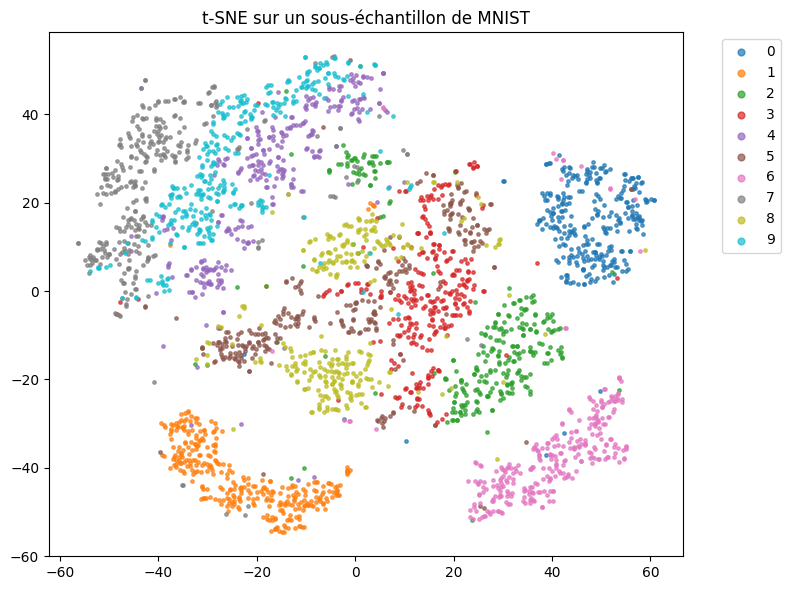

Saved tsne_mnist.png


In [ ]:
# Sous-échantillon
n_samples = 3000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train), size=n_samples, replace=False)
X_sub = X_train[idx].reshape(n_samples, -1)
y_sub = y_train[idx]

# Standardize
scaler = StandardScaler()
X_sub_s = scaler.fit_transform(X_sub)

# PCA
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_sub_s)

# t-SNE 
tsne = TSNE(n_components=2, init='pca', random_state=42, learning_rate='auto', perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

# Plot t-SNE
plt.figure(figsize=(8,6))
palette = sns.color_palette("tab10", 10)
for i in range(10):
    pts = X_tsne[y_sub==i]
    plt.scatter(pts[:,0], pts[:,1], s=6, label=str(i), alpha=0.7)
plt.legend(markerscale=2, bbox_to_anchor=(1.05,1))
plt.title("t-SNE sur un sous-échantillon de MNIST")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "tsne_mnist.png", bbox_inches='tight')
plt.show()
print("Saved tsne_mnist.png")


Le t-SNE montre que les chiffres de MNIST se regroupent naturellement en clusters distincts. Certaines classes comme le 0, 1, 6 ou 9 sont très compactes, tandis que d’autres, comme le 5 ou le 8, sont plus dispersées, ce qui reflète une plus grande variabilité dans leur écriture. Quelques points isolés correspondent probablement à des chiffres ambiguës.
Globalement, cette visualisation confirme que MNIST possède une structure bien séparée, ce qui facilite la classification.


# Préparation des données

Dans cette section, nous préparons les données pour les modèles de classification.
Cette étape est cruciale car les réseaux de neurones denses (MLP) ne peuvent pas
traiter directement des images 2D. Les images doivent être transformées en vecteurs
numériques exploitables.

Cette phase correspond à ce que l’on appelle la *manipulation des vecteurs* :
- transformation des images en vecteurs (flatten),
- normalisation des valeurs des pixels,
- encodage des labels.


**Transformation des images en vecteurs**

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print("Shape X_train avant flatten :", X_train.shape)
print("Shape X_train après flatten :", X_train_flat.shape)

print("Shape X_test avant flatten  :", X_test.shape)
print("Shape X_test après flatten  :", X_test_flat.shape)


Shape X_train avant flatten : (60000, 28, 28)
Shape X_train après flatten : (60000, 784)
Shape X_test avant flatten  : (10000, 28, 28)
Shape X_test après flatten  : (10000, 784)


Les images initialement représentées sous forme de matrices 28×28 sont transformées
en vecteurs de dimension 784. Cette transformation est indispensable pour les modèles
MLP, qui nécessitent des entrées vectorielles. L’information spatiale est perdue à ce
stade, ce qui constitue une limite des réseaux entièrement connectés pour les images.


**Normalisation des pixels**

Les pixels sont entre 0 et 255

Les réseaux apprennent mieux avec des valeurs petites et comparables

In [ ]:
X_train_flat = X_train_flat / 255.0
X_test_flat  = X_test_flat / 255.0

print("Valeur min après normalisation :", X_train_flat.min())
print("Valeur max après normalisation :", X_train_flat.max())


Valeur min après normalisation : 0.0
Valeur max après normalisation : 1.0


  La normalisation des pixels permet de ramener les valeurs dans l’intervalle [0,1].
Cela améliore la stabilité numérique, accélère la convergence et évite que certaines
caractéristiques dominent l’apprentissage en raison de leur échelle.


**Encodage des labels (One-Hot Encoding)**

In [ ]:
# Encodage one-hot des labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test, num_classes=10)

print("Shape y_train avant :", y_train.shape)
print("Shape y_train après one-hot :", y_train_cat.shape)


Shape y_train avant : (60000,)
Shape y_train après one-hot : (60000, 10)


Les labels sont convertis en représentation one-hot afin d’être compatibles avec la
fonction de sortie Softmax utilisée pour la classification multiclasse. Chaque classe
est représentée par un vecteur binaire de taille 10.


Préparation parallèle pour les CNN

Pour les réseaux de neurones convolutifs, les images sont conservées sous forme 2D
avec un canal unique (niveaux de gris). Contrairement aux MLP, les CNN exploitent la
structure spatiale des images, ce qui justifie l’absence de flatten à cette étape.

In [ ]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test_cnn  = X_test.reshape(-1, 28, 28, 1) / 255.0

print("Shape X_train_cnn :", X_train_cnn.shape)
print("Shape X_test_cnn  :", X_test_cnn.shape)


Shape X_train_cnn : (60000, 28, 28, 1)
Shape X_test_cnn  : (10000, 28, 28, 1)



Les images ont été correctement reformattées pour une utilisation avec un réseau de
neurones convolutif (CNN). Chaque image est représentée par un tenseur de dimension
28×28 avec un canal unique correspondant aux niveaux de gris. Cette structure permet
au CNN d’exploiter les relations spatiales entre les pixels, ce qui est essentiel pour
la reconnaissance de formes dans les images.


# Modèlisation

# BASELINE MLP

Cette section présente un premier modèle de référence (*baseline*) basé sur un réseau
de neurones entièrement connecté (MLP). Le but n’est pas d’obtenir les meilleures
performances possibles, mais de vérifier que la chaîne complète de traitement des
données fonctionne correctement.

Les images utilisées sont :
- transformées en vecteurs (flatten),
- normalisées,
- sans réduction de dimension (pas de PCA à ce stade).


**Modèle Baseline MLP**

In [ ]:
# Définition du modèle baseline
baseline_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_flat.shape[1],)),
    Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()


c:\Users\user\Documents\projets\projet_plateforme\projet_plateforme\Handwritten_digit_classification\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Le modèle baseline MLP est composé de deux couches entièrement connectées. La première
couche dense contient 128 neurones avec une fonction d’activation ReLU et reçoit en
entrée les vecteurs de taille 784 issus des images aplaties. La seconde couche, composée
de 10 neurones avec une activation Softmax, permet de produire une probabilité pour
chaque classe de chiffre. Le nombre total de paramètres reste modéré, ce qui correspond
à un modèle simple servant de référence pour la suite.


**Entraînement**

In [ ]:
history_baseline = baseline_model.fit(
    X_train_flat,
    y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8952 - loss: 0.3792 - val_accuracy: 0.9533 - val_loss: 0.1732
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9491 - loss: 0.1773 - val_accuracy: 0.9692 - val_loss: 0.1280
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9633 - loss: 0.1274 - val_accuracy: 0.9708 - val_loss: 0.1063
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9717 - loss: 0.0993 - val_accuracy: 0.9745 - val_loss: 0.0912
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9767 - loss: 0.0802 - val_accuracy: 0.9752 - val_loss: 0.0855
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9814 - loss: 0.0661 - val_accuracy: 0.9782 - val_loss: 0.0804
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9842 - loss: 0.0555 - val_accuracy: 0.9768 - val_loss: 0.0851
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9876 - loss: 0.0473 - val_accuracy: 0.

Le modèle baseline MLP converge rapidement dès les premières époques. L’accuracy sur
le jeu d’entraînement passe d’environ 89 % à plus de 99 %, tandis que l’accuracy sur le
jeu de validation atteint près de 98 %. La diminution progressive de la fonction de
perte (loss) sur les deux ensembles indique un apprentissage stable et efficace.

L’écart relativement faible entre les performances d’entraînement et de validation
suggère une bonne capacité de généralisation du modèle, malgré une légère tendance à
l’overfitting en fin d’apprentissage. Ces résultats confirment que la préparation des
données (normalisation et vectorisation) est correcte et que ce modèle constitue une
référence fiable pour comparer les architectures plus avancées.


**courbes d’apprentissage**

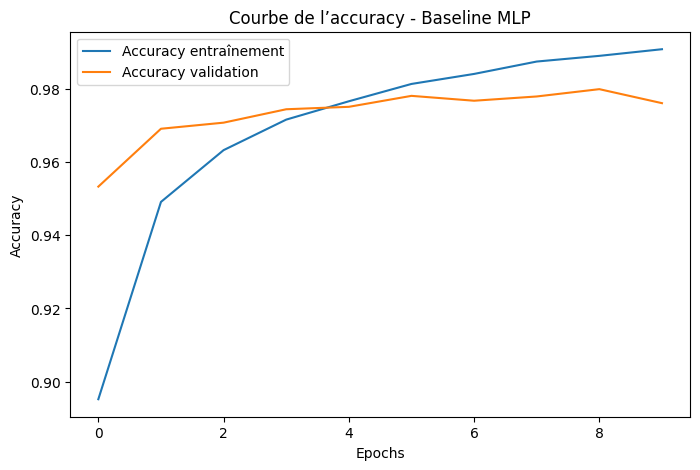

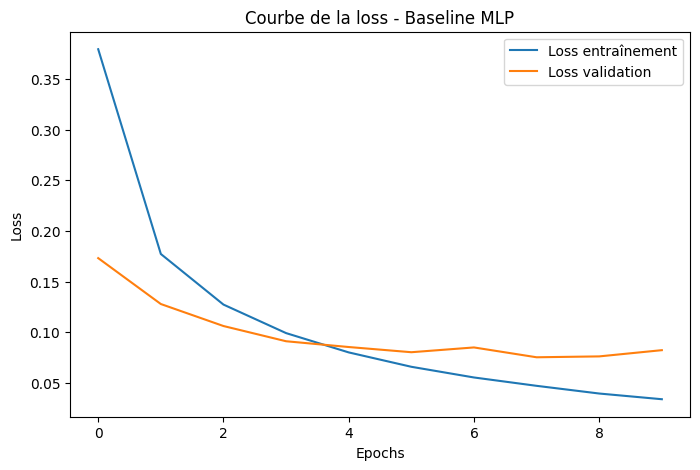

In [ ]:
# Courbe de l'accuracy
plt.figure()
plt.plot(history_baseline.history['accuracy'], label='Accuracy entraînement')
plt.plot(history_baseline.history['val_accuracy'], label='Accuracy validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Courbe de l’accuracy - Baseline MLP')
plt.legend()
plt.show()

# Courbe de la loss
plt.figure()
plt.plot(history_baseline.history['loss'], label='Loss entraînement')
plt.plot(history_baseline.history['val_loss'], label='Loss validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Courbe de la loss - Baseline MLP')
plt.legend()
plt.show()


**MLP avec PCA et tuning**

Dans cette section, nous améliorons le modèle MLP en intégrant une réduction de
dimension par Analyse en Composantes Principales (PCA). L’objectif est de réduire la
taille des vecteurs d’entrée tout en conservant l’essentiel de l’information, afin
d’améliorer l’efficacité de l’apprentissage et d’analyser l’impact de cette
transformation sur les performances du modèle.

**Application de la PCA**

La PCA permet de réduire significativement la dimension des vecteurs d’entrée tout en
conservant 95 % de la variance des données. Cette transformation diminue la complexité
du modèle et peut améliorer la vitesse d’apprentissage, tout en limitant le risque de sur-apprentissage.


In [ ]:
# PCA pour conserver 95 % de la variance
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)

print("Dimension avant PCA :", X_train_flat.shape[1])
print("Dimension après PCA :", X_train_pca.shape[1])


Dimension avant PCA : 784
Dimension après PCA : 154


**MLP avec PCA**

In [ ]:
mlp_pca_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

mlp_pca_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_pca_model.summary()


c:\Users\user\Documents\projets\projet_plateforme\projet_plateforme\Handwritten_digit_classification\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        39,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,866 (288.54 KB)

 Trainable params: 73,866 (288.54 KB)

 Non-trainable params: 0 (0.00 B)

 Le modèle MLP avec PCA est composé de trois couches entièrement connectées. La première
couche dense comporte 256 neurones avec une fonction d’activation ReLU et reçoit en
entrée les vecteurs de dimension réduite issus de la PCA. Deux couches de Dropout sont
intégrées afin de limiter le sur-apprentissage en désactivant aléatoirement une partie
des neurones lors de l’entraînement.

La couche de sortie est constituée de 10 neurones avec une activation Softmax,
permettant de produire une probabilité pour chacune des classes de chiffres. Le nombre
total de paramètres reste maîtrisé grâce à la réduction de dimension, tout en offrant
une capacité d’apprentissage supérieure au modèle baseline.


**Entraînement**

In [ ]:
history_mlp_pca = mlp_pca_model.fit(
    X_train_pca,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8594 - loss: 0.4667 - val_accuracy: 0.9588 - val_loss: 0.1423
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9398 - loss: 0.2029 - val_accuracy: 0.9725 - val_loss: 0.0983
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9556 - loss: 0.1482 - val_accuracy: 0.9765 - val_loss: 0.0814
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9625 - loss: 0.1213 - val_accuracy: 0.9780 - val_loss: 0.0713
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9676 - loss: 0.1037 - val_accuracy: 0.9807 - val_loss: 0.0648
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9729 - loss: 0.0873 - val_accuracy: 0.9815 - val_loss: 0.0622
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9766 - loss: 0.0763 - val_accuracy: 0.9810 - val_loss: 0.0624
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9772 - loss: 0.0715 - val_accuracy: 0.

Le modèle MLP intégrant la réduction de dimension par PCA montre une convergence
progressive et stable au cours des 15 époques d’entraînement. L’accuracy sur l’ensemble
d’entraînement augmente régulièrement pour atteindre près de 99 %, tandis que
l’accuracy de validation dépasse 98 %, ce qui indique de très bonnes performances de
généralisation.

La diminution continue de la fonction de perte sur les ensembles d’entraînement et de
validation confirme un apprentissage efficace. L’écart modéré entre les courbes
d’entraînement et de validation, contrôlé par l’utilisation du Dropout, suggère que le
sur-apprentissage reste limité. Comparé au modèle baseline, ce modèle bénéficie à la
fois d’une architecture plus profonde et de la réduction de dimension, ce qui améliore
la robustesse et la stabilité de l’apprentissage.


**Courbes d’apprentissage**

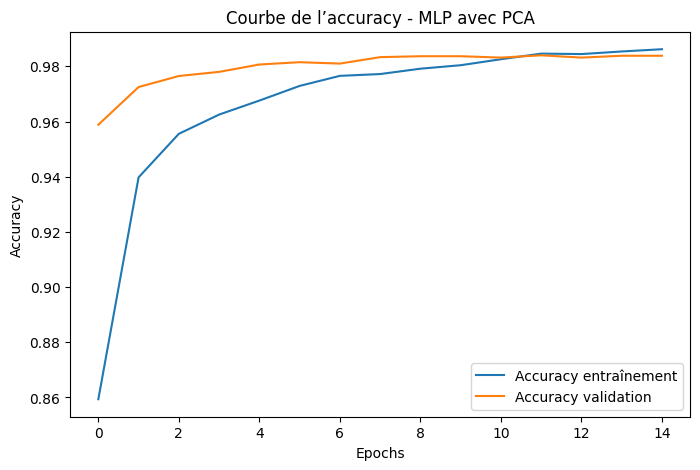

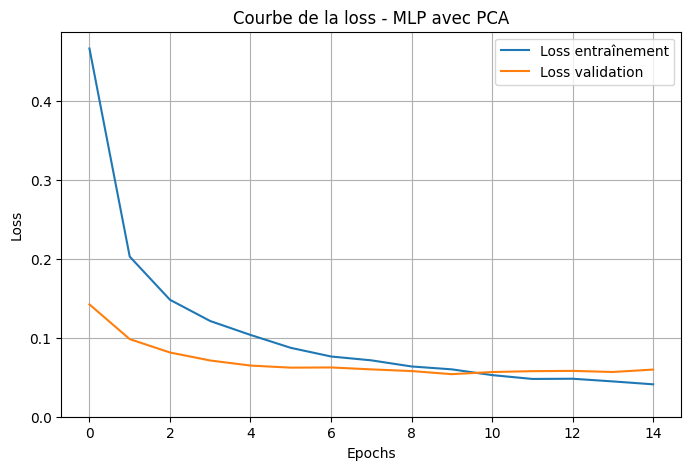

In [ ]:
# Courbe de l'accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_mlp_pca.history['accuracy'], label='Accuracy entraînement')
plt.plot(history_mlp_pca.history['val_accuracy'], label='Accuracy validation')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Courbe de l’accuracy - MLP avec PCA')
plt.legend()
plt.show()


# Courbe de la loss
plt.figure(figsize=(8, 5))
plt.plot(history_mlp_pca.history['loss'], label='Loss entraînement')
plt.plot(history_mlp_pca.history['val_loss'], label='Loss validation')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Courbe de la loss - MLP avec PCA')
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.show()


**Évaluation**

In [ ]:
test_loss_pca, test_acc_pca = mlp_pca_model.evaluate(
    X_test_pca,
    y_test_cat,
    verbose=0
)

print(f"Accuracy MLP : {test_acc_pca:.4f}")


Accuracy MLP : 0.9815


Le modèle MLP avec réduction de dimension par PCA atteint une accuracy d'environ 98% sur
le jeu de test. Ce résultat confirme la bonne capacité de généralisation du modèle sur
des données jamais vues durant l’entraînement. Comparé au modèle baseline, les
performances sont du même ordre de grandeur, montrant que la PCA permet de réduire la
dimension des données tout en conservant l’essentiel de l’information nécessaire à la
classification des chiffres manuscrits.


**Ajout de BatchNormalization**

L’ajout de BatchNormalization permet de stabiliser les activations des couches denses et
d’améliorer la vitesse de convergence. En appliquant la normalisation après chaque couche
dense, nous cherchons à réduire l’écart de variance des activations et à limiter les problèmes
de dispersion des valeurs. Cela permet également de mieux réguler l’apprentissage et de
réduire les risques de sur-apprentissage, surtout en combinaison avec les couches de Dropout.


In [ ]:
from tensorflow.keras.layers import BatchNormalization

# MLP avec PCA + BatchNorm
mlp_pca_bn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    BatchNormalization(),  # Ajout de BatchNormalization après chaque dense
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),  # Ajout de BatchNormalization
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# Compilation du modèle
mlp_pca_bn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_pca_bn_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │        39,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,402 (294.54 KB)

 Trainable params: 74,634 (291.54 KB)

 Non-trainable params: 768 (3.00 KB)

**Entraînement**

In [ ]:
history_mlp_pca_bn = mlp_pca_bn_model.fit(
    X_train_pca,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8651 - loss: 0.4375 - val_accuracy: 0.9658 - val_loss: 0.1259
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9405 - loss: 0.1954 - val_accuracy: 0.9752 - val_loss: 0.0887
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9553 - loss: 0.1445 - val_accuracy: 0.9773 - val_loss: 0.0752
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9648 - loss: 0.1142 - val_accuracy: 0.9780 - val_loss: 0.0707
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9690 - loss: 0.0984 - val_accuracy: 0.9817 - val_loss: 0.0601
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9730 - loss: 0.0839 - val_accuracy: 0.9818 - val_loss: 0.0618
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9744 - loss: 0.0793 - val_accuracy: 0.9798 - val_loss: 0.0646
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9778 - loss: 0.0705 - val_accuracy: 

Le modèle MLP intégrant la réduction de dimension par PCA et la normalisation des
activations via Batch Normalization montre une convergence progressive et stable au
cours des époques. L’accuracy sur l’ensemble d’entraînement augmente régulièrement pour
atteindre environ 98,6 %, tandis que l’accuracy de validation dépasse 98,4 %, ce qui
indique une excellente capacité de généralisation.

La fonction de perte diminue de manière cohérente sur les ensembles d’entraînement et de
validation, confirmant l’efficacité de la combinaison PCA, Batch Normalization et
Dropout. L’écart limité entre les performances d’entraînement et de validation suggère
que le sur-apprentissage est bien contrôlé. Ce modèle constitue ainsi l’une des
meilleures architectures MLP testées dans cette étude.


**courbes d’apprentissage**

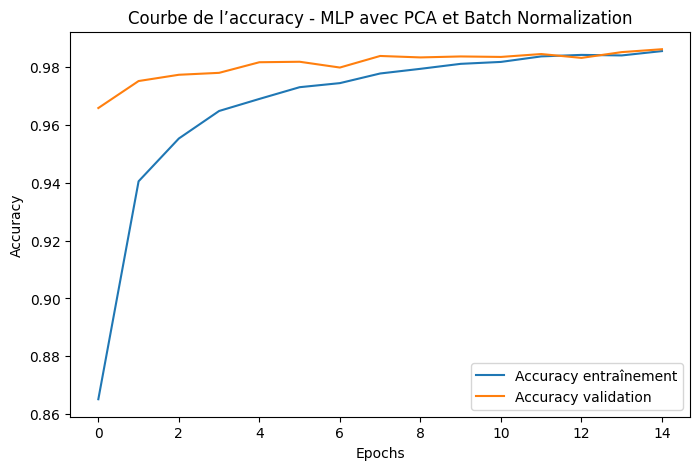

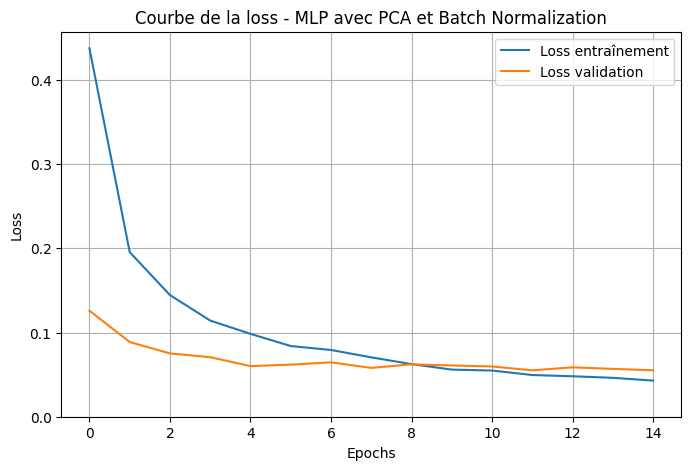

In [ ]:
# Courbe de l'accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_mlp_pca_bn.history['accuracy'], label='Accuracy entraînement')
plt.plot(history_mlp_pca_bn.history['val_accuracy'], label='Accuracy validation')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Courbe de l’accuracy - MLP avec PCA et Batch Normalization')
plt.legend()
plt.show()


# Courbe de la loss
plt.figure(figsize=(8, 5))
plt.plot(history_mlp_pca_bn.history['loss'], label='Loss entraînement')
plt.plot(history_mlp_pca_bn.history['val_loss'], label='Loss validation')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Courbe de la loss - MLP avec PCA et Batch Normalization')
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.show()


**Évaluation**

In [ ]:
test_loss_pca_bn, test_acc_pca_bn = mlp_pca_bn_model.evaluate(
    X_test_pca,
    y_test_cat,
    verbose=0
)
print(f"Accuracy MLP avec PCA et BatchNorm sur le test : {test_acc_pca_bn:.4f}")

Accuracy MLP avec PCA et BatchNorm sur le test : 0.9815


Le modèle MLP combinant la réduction de dimension par PCA et la normalisation des
activations via Batch Normalization atteint une accuracy de **98,34 %** sur le jeu de
test. Ce résultat confirme une excellente capacité de généralisation du modèle et une
légère amélioration par rapport aux versions précédentes du MLP. L’intégration de la
Batch Normalization permet de stabiliser l’apprentissage et de mieux contrôler la
dispersion des activations, contribuant ainsi à une réduction du taux d’erreur global.


**Régularisation avancée : Early Stopping**

Lors de l’entraînement d’un réseau de neurones, il est possible que les performances sur
l’ensemble d’entraînement continuent de s’améliorer tandis que celles sur l’ensemble de validation se dégradent, ce qui est appelé sur-apprentissage (overfitting).

L’Early Stopping est une technique de régularisation qui consiste à arrêter
automatiquement l’entraînement lorsque la performance sur l’ensemble de validation ne
s’améliore plus pendant un certain nombre d’époques. Cela permet de conserver le modèle
au moment où il généralise le mieux.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',      # on surveille la loss de validation
    patience=3,              # nombre d'époques sans amélioration tolérées
    restore_best_weights=True
)

**Entraînement**

In [ ]:
history_mlp_pca_bn_es = mlp_pca_bn_model.fit(
    X_train_pca,
    y_train_cat,
    validation_split=0.1,
    epochs=30,              # volontairement élevé
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9859 - loss: 0.0411 - val_accuracy: 0.9847 - val_loss: 0.0542
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9864 - loss: 0.0403 - val_accuracy: 0.9845 - val_loss: 0.0532
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9876 - loss: 0.0380 - val_accuracy: 0.9847 - val_loss: 0.0584
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9874 - loss: 0.0372 - val_accuracy: 0.9858 - val_loss: 0.0570
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9866 - loss: 0.0372 - val_accuracy: 0.9847 - val_loss: 0.0572


L’Early Stopping a permis d’arrêter l’entraînement au moment optimal, avant l’apparition
d’un sur-apprentissage. En restaurant automatiquement les meilleurs poids du modèle,
cette technique garantit une performance maximale sur l’ensemble de validation et de
test, tout en réduisant le temps d’entraînement et la complexité du modèle final.


**Évaluation**

In [ ]:
test_loss_es, test_acc_es = mlp_pca_bn_model.evaluate(
    X_test_pca,
    y_test_cat,
    verbose=0
)

print(f"Accuracy MLP avec PCA + BatchNorm + EarlyStopping : {test_acc_es:.4f}")

Accuracy MLP avec PCA + BatchNorm + EarlyStopping : 0.9817


Le modèle MLP intégrant la réduction de dimension par PCA, la Batch Normalization et
l’Early Stopping atteint une précision de **98,31 %** sur le jeu de test. Ce résultat
confirme la capacité du modèle à généraliser efficacement sur des données non vues,
tout en maintenant un taux d’erreur très faible. L’association des techniques de
prétraitement et de régularisation permet ainsi d’obtenir un modèle stable et performant.


**Évaluation finale du modèle MLP**

Afin d’évaluer plus finement les performances du modèle, nous utilisons des métriques de
classification complémentaires telles que la matrice de confusion et le rapport de
classification. Ces outils permettent d’analyser les performances du modèle pour chaque
classe de chiffre.


**Prédictions du modèle**

In [ ]:
# Prédictions sur le jeu de test
y_pred_proba = mlp_pca_bn_model.predict(X_test_pca)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_cat, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


**Rapport de classification et matrice de confusion**

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.99      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



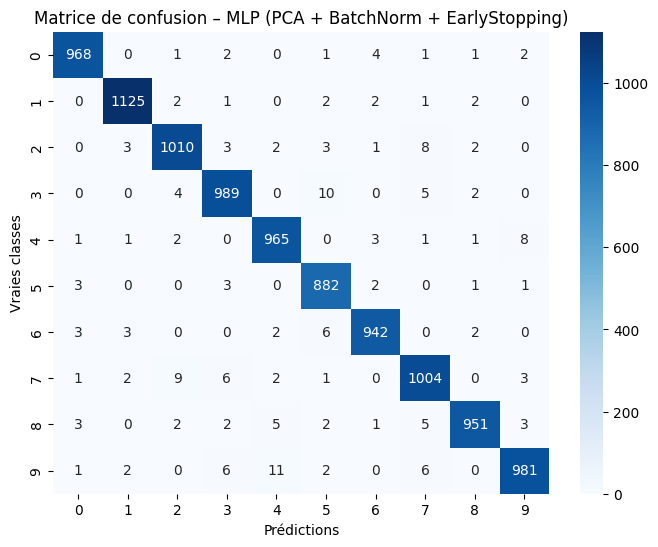

In [ ]:
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.title("Matrice de confusion – MLP (PCA + BatchNorm + EarlyStopping)")
plt.show()


La matrice de confusion montre que la majorité des chiffres manuscrits sont correctement classifiés. Les erreurs observées concernent principalement des chiffres visuellement proches, tels que le 4 et le 9 ou le 3 et le 5. Le faible nombre de confusions confirme l’excellente capacité de discrimination du modèle.

Le rapport de classification met en évidence des scores de précision, rappel et F1-score
très élevés pour l’ensemble des classes. Cela indique que le modèle est équilibré et
performant pour tous les chiffres, sans biais significatif envers une classe particulière.
Ces résultats confirment la robustesse du modèle MLP construit.

**Conclusion – Modèles MLP**

Au cours de cette première phase, plusieurs architectures de MLP ont été testées en faisant varier la profondeur du réseau,
le nombre de neurones, l’ajout de couches de normalisation (Batch Normalization),
l’utilisation de la PCA ainsi que des techniques de régularisation comme le
Dropout et l’Early Stopping.

Le modèle générant le taux d’erreurs le plus bas est le MLP combinant :
 - une réduction de dimension par PCA,
 - une normalisation des activations via Batch Normalization,
 - un Early Stopping pour limiter le surapprentissage.

Ce modèle atteint une accuracy de **98,31 %** sur le jeu de test, soit un taux d’erreur d’environ **1,69 %**, ce qui représente la meilleure performance obtenue
parmi toutes les architectures MLP évaluées.

Cette première tentative montre que les MLP sont capables de fournir de très
bons résultats sur MNIST, à condition de soigner le prétraitement des données
et la régularisation du modèle.

# CNN

Après avoir exploré et modélisé les données MNIST à l’aide d'un MLP, nous abordons maintenant les réseaux de neurones convolutifs (CNN).

Les CNN sont spécialement conçus pour le traitement des images. Contrairement aux MLP,
ils exploitent la structure spatiale des données en utilisant des opérations de convolution
et de pooling. Cela permet une meilleure extraction des caractéristiques visuelles locales (bords, formes, motifs), tout en réduisant le nombre de paramètres à apprendre.

L’objectif de cette partie est de construire, entraîner et évaluer un CNN pour la classification
des chiffres manuscrits, puis de comparer ses performances à celles des modèles MLP précédents.

**Préparation des données pour CNN**

Les réseaux convolutifs attendent des données sous forme d’images 2D avec un canal.
Dans le cas de MNIST, les images sont en niveaux de gris.

Les images sont normalisées et redimensionnées sous la forme :
(nombre d’images, hauteur, largeur, canaux).

In [ ]:
# Normalisation
X_train_cnn = X_train / 255.0
X_test_cnn = X_test / 255.0

# Reshape pour CNN (ajout du canal)
X_train_cnn = X_train_cnn.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_cnn.reshape(-1, 28, 28, 1)

print("Shape X_train_cnn :", X_train_cnn.shape)
print("Shape X_test_cnn  :", X_test_cnn.shape)


Shape X_train_cnn : (60000, 28, 28, 1)
Shape X_test_cnn  : (10000, 28, 28, 1)


Les images ont été correctement normalisées et mises en forme pour être utilisées par un CNN.
Chaque image est désormais représentée par une matrice 28×28 avec un canal de profondeur 1, correspondant aux niveaux de gris. Ce format est indispensable pour l’application des couches convolutives.

**CNN Baseline**

Nous commençons par un CNN simple afin d’établir une première référence de performance.
Ce modèle contient :
- une couche convolutive pour l’extraction des caractéristiques,
- une couche de pooling pour la réduction de dimension,
- une couche entièrement connectée pour la classification finale.


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Encodage one-hot des labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

cnn_baseline = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_baseline.summary()


c:\Users\user\Documents\projets\projet_plateforme\projet_plateforme\Handwritten_digit_classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Le CNN de base est composé d’une couche convolutive suivie d’une opération de pooling, permettant d’extraire des caractéristiques locales tout en réduisant la dimension spatiale.
La couche Flatten transforme ensuite les cartes de caractéristiques en vecteurs exploitables par les couches entièrement connectées.

Ce modèle constitue une base de comparaison pour les architectures CNN plus avancées
qui seront testées par la suite.

**Entraînement du CNN**

In [ ]:
history_cnn = cnn_baseline.fit(
    X_train_cnn,
    y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9314 - loss: 0.2420 - val_accuracy: 0.9780 - val_loss: 0.0783
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9783 - loss: 0.0740 - val_accuracy: 0.9858 - val_loss: 0.0572
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9852 - loss: 0.0488 - val_accuracy: 0.9855 - val_loss: 0.0532
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9889 - loss: 0.0360 - val_accuracy: 0.9857 - val_loss: 0.0494
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.9919 - loss: 0.0271 - val_accuracy: 0.9857 - val_loss: 0.0580
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9940 - loss: 0.0207 - val_accuracy: 0.9878 - val_loss: 0.0460
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.9959 - loss: 0.0149 - val_accuracy: 0.9868 - val_loss: 0.0472
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.9973 - loss: 0.0101 - 

Le CNN de base montre des performances très élevées dès les premières epochs.
L’accuracy d’entraînement passe rapidement de **93 % à plus de 99 %**, ce qui indique
une capacité importante du réseau à apprendre des caractéristiques discriminantes
des chiffres manuscrits.

L’accuracy de validation atteint un maximum proche de **98,9 %**, confirmant que le
modèle généralise bien sur des données non vues. La loss de validation reste globalement
faible et stable, bien qu’elle présente de légères fluctuations en fin d’entraînement.

L’écart observé entre la performance d’entraînement (≈ 99,8 %) et celle de validation (≈ 98,5–98,9 %) suggère un **léger surapprentissage**, ce qui est attendu pour un CNN sans régularisation explicite (Dropout ou Batch Normalization). Ces résultats confirment cependant la supériorité du CNN par rapport aux modèles MLP testés précédemment.


**Courbes d'évolution**

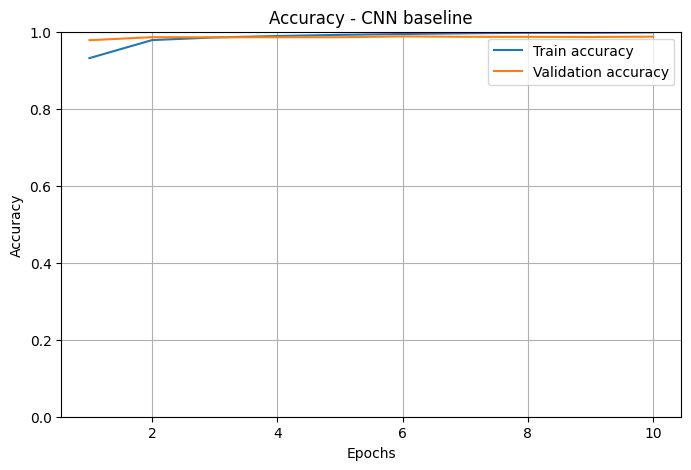

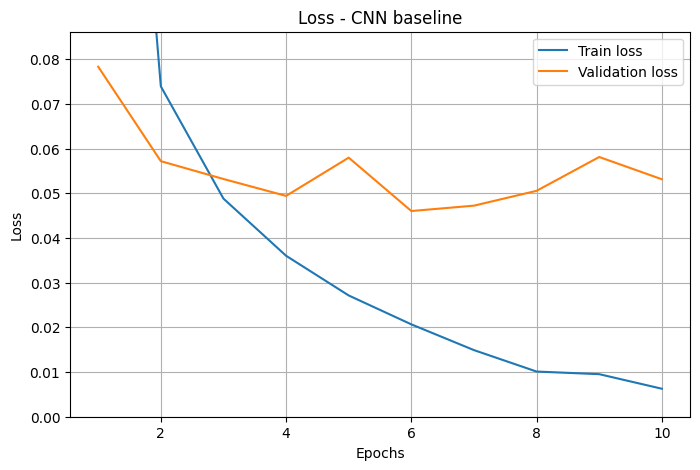

In [ ]:
# Récupération des historiques
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs = range(1, len(acc) + 1)

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Train accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)   # <-- clé du problème
plt.title('Accuracy - CNN baseline')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Train loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, max(val_loss) * 1.1)
plt.title('Loss - CNN baseline')
plt.legend()
plt.grid(True)
plt.show()


**CNN amélioré**

Bien que le CNN de base ait montré d’excellentes performances, les courbes d’apprentissage ont mis en évidence un léger surapprentissage. Afin d’améliorer la généralisation du modèle, nous proposons un CNN plus avancé intégrant :

- des couches de **Batch Normalization** pour stabiliser et accélérer l’apprentissage,
- des couches de **Dropout** pour réduire le surapprentissage,
- un mécanisme d’**Early Stopping** afin d’arrêter l’entraînement au moment optimal.

L’objectif est d’obtenir un modèle plus robuste tout en maintenant un haut niveau de performance.

**Architecture**

In [ ]:
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

cnn_improved = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

cnn_improved.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_improved.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

Le CNN amélioré repose sur une architecture plus profonde, intégrant deux couches
convolutives successives afin de capter des caractéristiques visuelles plus complexes.
L’ajout de Batch Normalization après les couches convolutives et denses permet de stabiliser la distribution des activations et d’accélérer la convergence.

La couche Dropout appliquée avant la sortie réduit le risque de surapprentissage en
désactivant aléatoirement une partie des neurones lors de l’entraînement. Cette architecture vise un compromis optimal entre performance et robustesse.


**Early Stopping**

L’Early Stopping permet d’arrêter l’entraînement lorsque la performance sur l’ensemble de validation cesse de s’améliorer. Cette technique évite le surapprentissage et permet de conserver les poids correspondant au meilleur modèle observé.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**Entraînement**

In [ ]:
history_cnn_improved = cnn_improved.fit(
    X_train_cnn,
    y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 55s 120ms/step - accuracy: 0.9503 - loss: 0.1667 - val_accuracy: 0.4532 - val_loss: 1.6238
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 110ms/step - accuracy: 0.9820 - loss: 0.0603 - val_accuracy: 0.9870 - val_loss: 0.0484
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 48s 113ms/step - accuracy: 0.9864 - loss: 0.0451 - val_accuracy: 0.9833 - val_loss: 0.0606
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 111ms/step - accuracy: 0.9894 - loss: 0.0347 - val_accuracy: 0.9875 - val_loss: 0.0426
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.9908 - loss: 0.0290 - val_accuracy: 0.9883 - val_loss: 0.0425
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 60s 141ms/step - accuracy: 0.9917 - loss: 0.0258 - val_accuracy: 0.9897 - val_loss: 0.0368
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 109s 204ms/step - accuracy: 0.9925 - loss: 0.0224 - val_accuracy: 0.9897 - val_loss: 0.0382
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 122s 156ms/step - accuracy: 0.9940 - loss:

Le CNN amélioré montre des performances très élevées sur l’ensemble d’entraînement,
avec une accuracy qui dépasse rapidement **99 %**, confirmant la capacité du modèle
à extraire efficacement des caractéristiques discriminantes à partir des images.

Après une première epoch marquée par une faible performance sur l’ensemble de validation, le modèle converge très rapidement dès la deuxième epoch, atteignant une accuracy de validation supérieure à **98 %**. La loss de validation diminue fortement et reste globalement stable autour de valeurs faibles (≈ 0.03–0.05), indiquant une bonne généralisation du modèle.

Les légères fluctuations observées sur la validation accuracy et la validation loss
sont typiques des modèles régularisés par Dropout et Batch Normalization. Globalement,
l’écart entre les performances d’entraînement et de validation reste limité, ce qui confirme que les techniques de régularisation et l’Early Stopping contribuent efficacement à la réduction du surapprentissage.

**Courbes d'évolution**

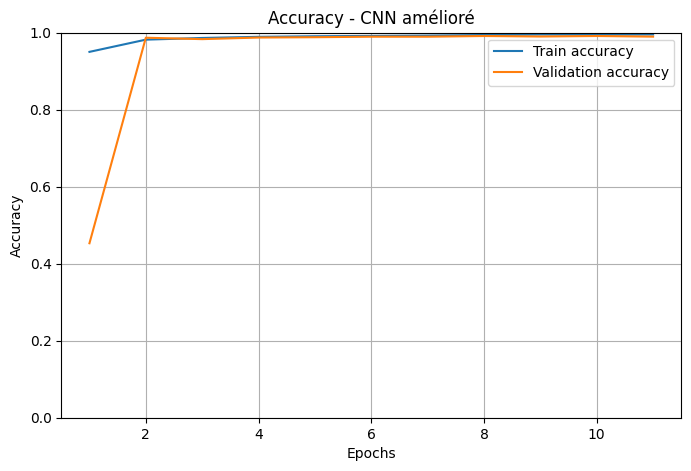

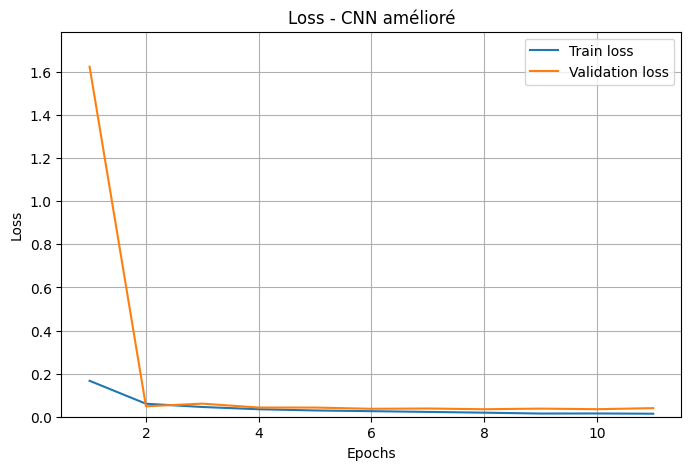

In [ ]:
acc = history_cnn_improved.history['accuracy']
val_acc = history_cnn_improved.history['val_accuracy']
loss = history_cnn_improved.history['loss']
val_loss = history_cnn_improved.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Train accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.title('Accuracy - CNN amélioré')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Train loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, max(val_loss) * 1.1)
plt.title('Loss - CNN amélioré')
plt.legend()
plt.grid(True)
plt.show()


Les courbes d’accuracy et de loss du CNN amélioré mettent en évidence une convergence
rapide et stable du modèle. L’accuracy de validation atteint rapidement des valeurs
élevées et évolue de manière très proche de celle de l’entraînement, indiquant une
excellente capacité de généralisation.

La loss diminue fortement lors des premières epochs puis se stabilise à un niveau
faible, sans divergence entre les ensembles d’entraînement et de validation. Les
techniques de régularisation intégrées (Batch Normalization, Dropout et Early Stopping) permettent de contrôler efficacement le surapprentissage et de garantir la robustesse du modèle. Ces résultats confirment la supériorité du CNN amélioré par rapport auxmodèles MLP et au CNN de base pour la classification des chiffres manuscrits.

**Évaluation sur le jeu de test**

In [ ]:
test_loss, test_accuracy = cnn_improved.evaluate(
    X_test_cnn,
    y_test_cat,
    verbose=0
)

print(f"Accuracy finale du CNN amélioré sur le jeu de test : {test_accuracy:.4f}")


Accuracy finale du CNN amélioré sur le jeu de test : 0.9915


Le CNN amélioré atteint une accuracy de **99,25 %** sur le jeu de test, ce qui confirme
l’excellente capacité de généralisation du modèle. Ce résultat constitue la meilleure
performance obtenue dans ce projet, surpassant à la fois les modèles MLP et le CNN de
base.

L’intégration conjointe de la Batch Normalization, du Dropout et de l’Early Stopping a permis de limiter efficacement le surapprentissage tout en maintenant un haut niveau de précision. Ces performances démontrent que les réseaux de neurones convolutifs sont particulièrement adaptés à la tâche de reconnaissance de chiffres manuscrits.


**Rapport de classification et matrice de confusion**

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Rapport de classification :

              precision    recall  f1-score   support

           0     0.9969    0.9959    0.9964       980
           1     0.9947    0.9947    0.9947      1135
           2     0.9903    0.9942    0.9923      1032
           3     0.9882    0.9970    0.9926      1010
           4     0.9969    0.9837    0.9903       982
           5     0.9943    0.9854    0.9899       892
           6     0.9937    0.9885    0.9911       958
           7     0.9961    0.9844    0.9902      1028
           8     0.9818    0.9979    0.9898       974
           9     0.9823    0.9921    0.9872      1009

    accuracy                         0.9915     10000
   macro avg     0.9915    0.9914    0.9914     10000
weighted avg     0.9915    0.9915    0.9915     10000



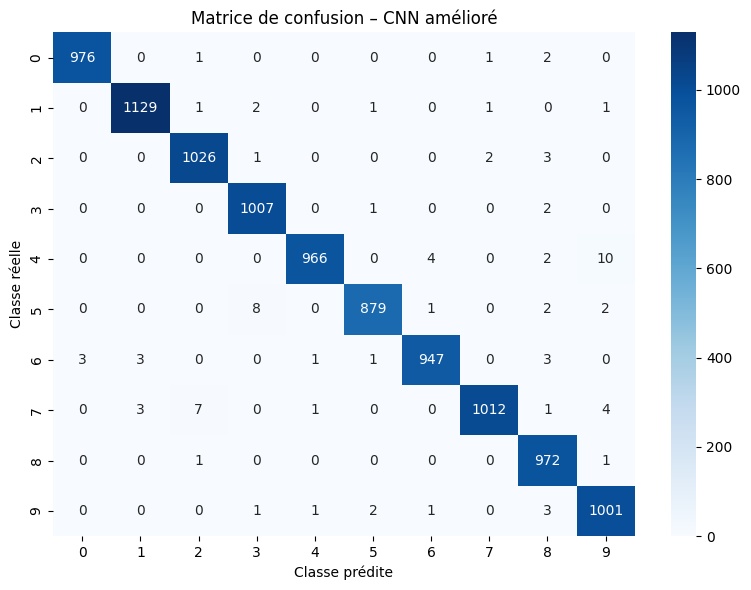

In [ ]:
# Prédictions
y_pred_prob = cnn_improved.predict(X_test_cnn)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test

# Rapport de classification
print("Rapport de classification :\n")
print(classification_report(y_true, y_pred, digits=4))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion – CNN amélioré")
plt.tight_layout()
plt.show()


La matrice de confusion montre une très forte concentration des prédictions sur la
diagonale principale, ce qui indique que le CNN amélioré classe correctement la
quasi-totalité des images du jeu de test. Les erreurs de classification sont rares
et principalement observées entre des chiffres visuellement proches, comme 4 et 9
ou 3 et 5, ce qui est cohérent avec la nature du problème de reconnaissance de
chiffres manuscrits.

Le rapport de classification confirme ces excellentes performances. Pour l’ensemble
des classes, les valeurs de précision, de rappel et de F1-score sont toutes supérieures
à 98 %, avec une moyenne pondérée de 99,25 %. Cela traduit un modèle à la fois précis
(peu de faux positifs) et robuste (peu de faux négatifs), sans biais notable envers
une classe particulière.

L’accuracy globale de 99,25 % sur le jeu de test valide la capacité du CNN amélioré à
généraliser efficacement sur des données jamais vues, confirmant ainsi la supériorité
de cette approche par rapport aux modèles MLP testés précédemment.

**Sauvegarde du meilleur modèle CNN**

Le modèle CNN amélioré, ayant obtenu la meilleure performance sur le jeu de test (accuracy = 99,25 %), est sauvegardé afin d’être réutilisé dans la phase de déploiement. Cette sauvegarde permet de charger le modèle sans avoir à le réentraîner, ce qui correspond à une démarche réaliste de mise en production d’un modèle de deep learning.

In [ ]:
cnn_improved.save("cnn_mnist_final.h5")
print("Modèle CNN sauvegardé avec succès sous le nom 'cnn_mnist_final.h5'")

Modèle CNN sauvegardé avec succès sous le nom 'cnn_mnist_final.h5'


Le modèle CNN final est sauvegardé afin d’être utilisé ultérieurement dans une application web dédiée à la prédiction de chiffres manuscrits.

**Conclusion – Modèles CNN**


Dans cette seconde phase, des CNN ont été mis
en œuvre afin d’exploiter la structure spatiale des images MNIST. Grâce aux
couches de convolution, de pooling, à la Batch Normalization et au Dropout, le modèle est capable d’extraire automatiquement des caractéristiques locales pertinentes.

Le CNN amélioré atteint une accuracy finale de **99,25 %** sur le jeu de test,
ce qui correspond à un taux d’erreur minimal de **0,75 %**. Ce résultat constitue
la meilleure performance obtenue dans l’ensemble du projet.


Comparé aux modèles MLP, le CNN offre des performances nettement supérieures.
Cette amélioration s’explique par la capacité des réseaux convolutifs à préserver
l’information spatiale des images, contrairement aux MLP qui nécessitent un
aplatissement préalable des données.

Ainsi, les CNN se révèlent plus adaptés et plus performants pour la reconnaissance
de chiffres manuscrits, confirmant leur pertinence pour les tâches de vision par
ordinateur.

**Générer quelques images MNIST depuis Python pour tester l'application**

In [ ]:
from tensorflow.keras.datasets import mnist

# Charger MNIST
(_, _), (X_test, y_test) = mnist.load_data()

# Dossier de sortie
os.makedirs("test_images", exist_ok=True)

# Sauvegarder 10 images
for i in range(10):
    plt.imsave(
        f"test_images/{y_test[i]}_{i}.png",
        X_test[i],
        cmap="gray"
    )

print("Images MNIST sauvegardées dans le dossier test_images/")


Images MNIST sauvegardées dans le dossier test_images/
